In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df=sns.load_dataset('iris')

In [ ]:

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.drop(['sepal_length','sepal_width','species'],axis=1,inplace=True)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
df.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [ ]:
inertia=[]
K_range=range(1,11)

In [ ]:
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
inertia

[28.36835321972719,
 5.176463590044366,
 1.701874688192097,
 1.1826561791866754,
 0.9618843938398448,
 0.6889019224531718,
 0.566867830638765,
 0.5416444734655237,
 0.4714234315452125,
 0.40230484926891924]

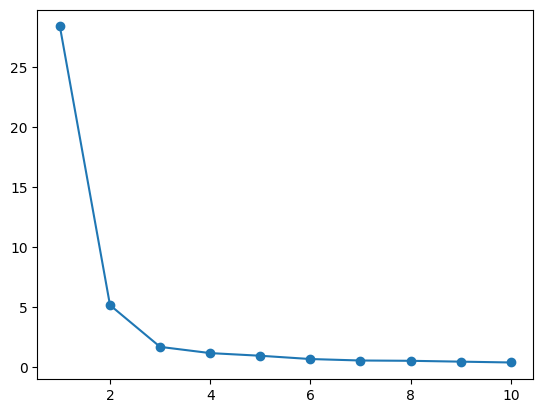

In [ ]:
plt.plot(K_range,inertia, marker='o')


In [ ]:
kmean_final=KMeans(n_clusters=3,random_state=42)

In [ ]:
cluser_labels=kmean_final.fit_predict(X_scaled)

In [ ]:
df['cluster']=cluser_labels

<Axes: xlabel='petal_length', ylabel='petal_width'>

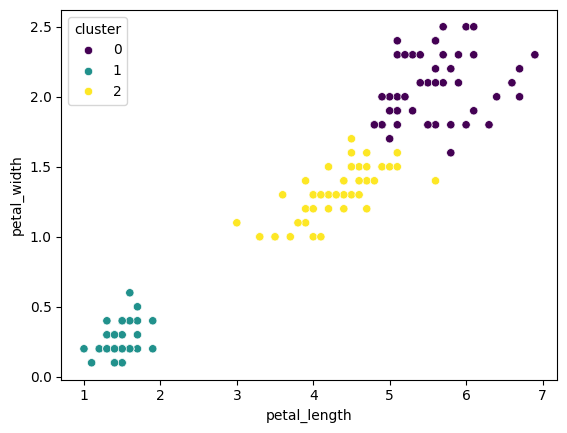

In [ ]:
sns.scatterplot(x=df["petal_length"],
                y=df["petal_width"],
                hue=df["cluster"],
                palette="viridis")

In [ ]:
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = sns.load_dataset("iris")


In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
results=pd.DataFrame(grid_search.cv_results_)

In [ ]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_criterion', 'param_max_depth', 'param_min_samples_leaf',
       'param_min_samples_split', 'param_n_estimators', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [ ]:
results[['params','mean_test_score']]

,params,mean_test_score
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.950000
1,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.950000
2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.950000
3,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.950000
4,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.950000
...,...,...
211,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.950000
212,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.950000
213,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.941667
214,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.950000
